In [123]:
%%writefile mi_script.py


Overwriting mi_script.py


In this project, we reverse the paradigm discussed in lectures so far: rather than start with a model and infer properties of realizations, we will start with an observed realization of a time series and infer details about models which may have generated the observations.

For the project, we have provided two datasets as follows. (Note that these two files are an archived version of the online Zillow database). Click to download the data files below:

zillow_house_prices.csv, data from Zillow which contains a smoothed, seasonally adjusted measure of the typical home value and market changes across a given region and housing type. It reflects the typical value for homes in the 35th to 65th percentile range.

interest_rates.csv, data from FRED which contains monthly published interest rates.

In [124]:
import numpy as np
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')


In [125]:
df = pd.read_csv('/content/data_zillow_house_prices.csv')

In [126]:
#count rows excluding header
print('Rows:', len(df))

Rows: 893


In [127]:
#missing data
print(df.isnull().sum().sum())

49520


In [128]:
#unique region count
print(df['RegionType'].nunique())

2


In [129]:
#type of regions
print(df['RegionType'].unique())

['country' 'msa']


In [130]:
  #This dataset is basically a large data matrix. Which of the following term represents a time series?
print(df.columns.tolist()[:10])
print(df.columns.tolist()[-10:])

['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', '2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31']
['2021-11-30', '2021-12-31', '2022-01-31', '2022-02-28', '2022-03-31', '2022-04-30', '2022-05-31', '2022-06-30', '2022-07-31', '2022-08-31']


In [131]:
# Each row = one region. Select a single row and look at its date columns.
date_cols = [c for c in df.columns if c.startswith('20')]
# A row's values across date columns = its time series
print(df[date_cols].iloc[0])

2000-01-31    127881.0
2000-02-29    128227.0
2000-03-31    128591.0
2000-04-30    129332.0
2000-05-31    130079.0
                ...   
2022-04-30    343392.0
2022-05-31    348415.0
2022-06-30    352585.0
2022-07-31    354986.0
2022-08-31    356026.0
Name: 0, Length: 272, dtype: float64


In [132]:
# Calculate the difference between consecutive dates
dates = pd.to_datetime(date_cols)
diffs = dates[1:] - dates[:-1]
print(diffs[:5])

TimedeltaIndex(['29 days', '31 days', '30 days', '31 days', '30 days'], dtype='timedelta64[ns]', freq=None)


In [133]:
df1 = pd.read_csv('/content/data_interest_rates.csv')
print(df1.head())

         DATE  MORTGAGE30US
0  1971-04-02          7.33
1  1971-04-09          7.31
2  1971-04-16          7.31
3  1971-04-23          7.31
4  1971-04-30          7.29


In [134]:
df1['DATE'] = pd.to_datetime(df1['DATE'])


In [135]:
#first year entered
print(df1['DATE'].dt.year.min())

1971


In [136]:
#missing data
print(df1.isnull().sum().sum())

0


In [137]:
#min and max mortage rate
print(df1['MORTGAGE30US'].min() / 100)
print(df1['MORTGAGE30US'].max() / 100)

0.0265
0.1863


In [138]:
#sampling frequency
diffs = df1['DATE'].diff().dropna()

# Most common gap = the sampling frequency
print(diffs.mode()[0])

7 days 00:00:00


Problem 1: Stationarity in Time Series

With the given datasets, our focus is on the modeling and prediction of the housing prices in Boston, MA. But before diving into the detailed prediction, it is common to analyze the trend and get some basic understanding of the data. You are expected to get the target housing prices from the original dataset by filtering the “RegionName" column. Next, use these data to answer the following questions.

In [139]:
# Plot the time series of housing prices in Boston, MA, and describe the overall trends in the dataset. Which of the following figures are showing the trends you may find for Boston?

boston = df[df['RegionName'] == 'Boston, MA']


In [140]:
# Get all date columns (they all start with '20')
date_cols = [c for c in df.columns if c.startswith('20')]

# Get the single Boston row's values for those columns
prices = boston[date_cols].iloc[0]

# Convert the index (column names) to proper datetime
prices.index = pd.to_datetime(prices.index)

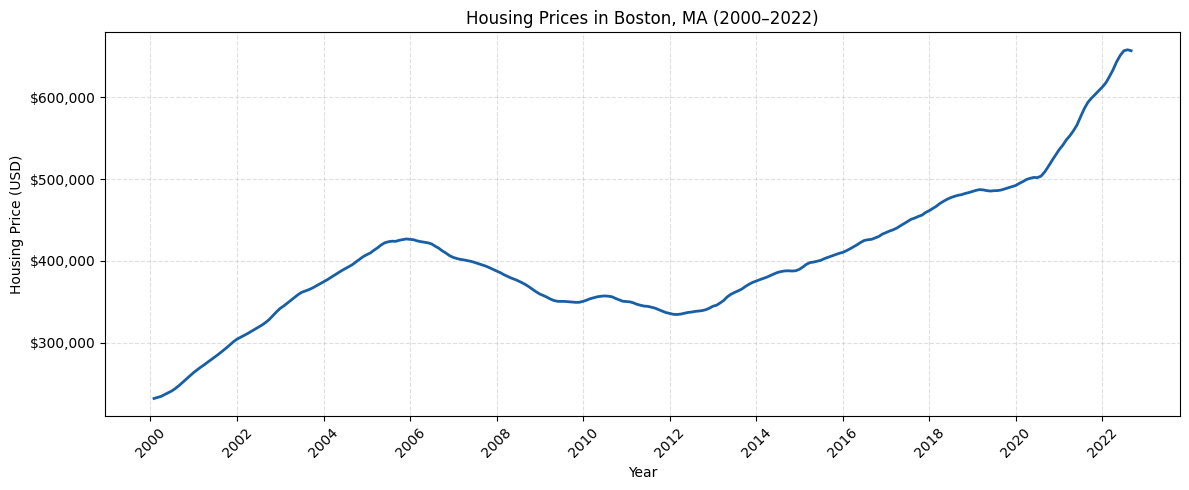

In [141]:
#plotting the time series

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(prices.index, prices.values, color='#185FA5', linewidth=2)

ax.set_title('Housing Prices in Boston, MA (2000–2022)')
ax.set_xlabel('Year')
ax.set_ylabel('Housing Price (USD)')

# Format y-axis as dollar amounts
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# Show a tick every 2 years on x-axis
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('boston_housing_prices.png', dpi=150)
plt.show()

2. There are several ways to model this trend. Which of the following options might be the best fit?

- A cubic curve with a positive coefficient for the third-degree term
- A cubic curve with a negative coefficient for the third-degree term
- A piecewise linear curve with four segments
- A piecewise linear curve with three segments

**Answer**
The curve shows three distinct phases: a moderate rise (2000–2006), a flat/slight dip (2006–2012), and a steep accelerating rise (2012–2022).

The dashed orange line below shows how a piecewise linear model with three segments captures the shape well — a rising segment (2000–2006), a declining/flat segment (2006–2012), and a steep rising segment (2012–2022).

both the cubic options wouldn't fit but the linear curve with four segments would apply to this plot.

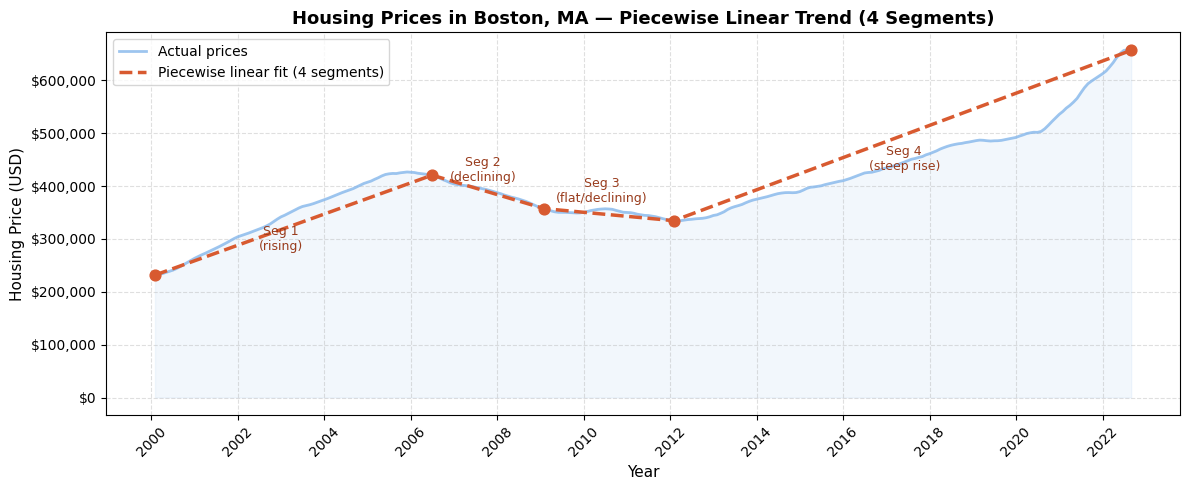

In [142]:
date_cols = [c for c in df.columns if c.startswith('20')]
prices = boston[date_cols].iloc[0]
prices.index = pd.to_datetime(prices.index)

# --- 2. Define piecewise breakpoints (4 segments = 5 points) ---
# Seg 1: rising       (2000–2006)
# Seg 2: declining    (2006–2009)
# Seg 3: flat/decline (2009–2012)
# Seg 4: steep rise   (2012–2022)
breakpoints = pd.to_datetime([
    '2000-01-31',
    '2006-06-30',
    '2009-01-31',
    '2012-01-31',
    '2022-08-31'
])
bp_prices = [231718, 420805, 357503, 334657, 657035]

# --- 3. Interpolate piecewise linear fit ---
pw_fit = np.interp(
    prices.index.astype(np.int64),   # all dates as integers
    breakpoints.astype(np.int64),    # breakpoint dates as integers
    bp_prices                        # prices at each breakpoint
)

# --- 4. Plot ---
fig, ax = plt.subplots(figsize=(12, 5))

# Actual prices
ax.plot(prices.index, prices.values,
        color='#85B7EB', linewidth=2, label='Actual prices', alpha=0.8)
ax.fill_between(prices.index, prices.values, alpha=0.1, color='#85B7EB')

# Piecewise linear fit
ax.plot(prices.index, pw_fit,
        color='#D85A30', linewidth=2.5, linestyle='--',
        label='Piecewise linear fit (4 segments)')

# Breakpoint markers
ax.scatter(breakpoints, bp_prices, color='#D85A30', zorder=5, s=60)

# Segment labels
segments = [
    ('2003-01-01', 280000, 'Seg 1\n(rising)'),
    ('2007-09-01', 410000, 'Seg 2\n(declining)'),
    ('2010-06-01', 370000, 'Seg 3\n(flat/declining)'),
    ('2017-06-01', 430000, 'Seg 4\n(steep rise)'),
]
for date, y, label in segments:
    ax.annotate(label, xy=(pd.Timestamp(date), y),
                fontsize=9, color='#993C1D', ha='center')

# Formatting
ax.set_title('Housing Prices in Boston, MA — Piecewise Linear Trend (4 Segments)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Housing Price (USD)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('boston_piecewise_4seg.png', dpi=150)
plt.show()

2. Data Stationarity Analysis

Below, we stick to the housing prices (Boston, MA) from January 2010 to December 2017 (closed interval). Take care of date filter and check if the boundary days are correctly included.

A standard process to test the stationarity of a time series is to run the augmented Dickey-Fuller test. If the test reports p>0.05 try removing a linear term and then other polynomial terms (quadratic, cubic, etc) until the test reports p <0.05.

From the augmented Dickey-Fuller test, what is the p-value of the original price series? Hint: Rounded to three decimal places. You may use “statsmodels.tsa.stattools.adfuller" and keep the default arguments to match the grader.

In [143]:
boston = df[df['RegionName'] == 'Boston, MA']
date_cols = [c for c in df.columns if c.startswith('20')]
prices = boston[date_cols].iloc[0]
prices.index = pd.to_datetime(prices.index)



In [144]:
# Closed interval — both endpoints included
mask = (prices.index >= '2010-01-01') & (prices.index <= '2017-12-31')
series = prices[mask]

In [145]:
def run_adf(s, label):
    result = adfuller(s)   # default arguments as required
    p = round(result[1], 3)  # result[1] is the p-value
    status = 'STATIONARY' if p < 0.05 else 'NOT stationary'
    print(f"{label}: p = {p} → {status}")
    return p

In [146]:
from statsmodels.tsa.stattools import adfuller
#testing the original series
run_adf(series, "Original")
# p = 0.979 → NOT stationary

Original: p = 0.979 → NOT stationary


np.float64(0.979)

In [147]:
#since p > 0.05, remove polynomial trends and running again

t = np.arange(len(series))

In [148]:
# Linear trend removal (degree=1)
lin_coef  = np.polyfit(t, series.values, 1)
lin_trend = np.polyval(lin_coef, t)
run_adf(series.values - lin_trend, "Linear removed")

Linear removed: p = 0.033 → STATIONARY


np.float64(0.033)

In [149]:
# Linear + quadratic removal (degree=2)
quad_coef  = np.polyfit(t, series.values, 2)
quad_trend = np.polyval(quad_coef, t)
run_adf(series.values - quad_trend, "Linear + quadratic removed")

Linear + quadratic removed: p = 0.035 → STATIONARY


np.float64(0.035)

In [150]:
# Linear + quadratic + cubic removal (degree=3)
cub_coef  = np.polyfit(t, series.values, 3)
cub_trend = np.polyval(cub_coef, t)
run_adf(series.values - cub_trend, "Linear + quadratic + cubic removed")

Linear + quadratic + cubic removed: p = 0.002 → STATIONARY


np.float64(0.002)

Autocorrelation

From the previous discussion, you should be able to stablize the housing price data. Note that you are expected to use the simplest option from the above question in “Data Stationarity Analysis" to align with the grader.

Next, we will analyze the stationary time series with the autocorrelation function (ACF) and the partial autocorrelation function (PACF).

Hint : Use the “statsmodels.graphics.tsaplots" package in Python to get the figures.

Which of the following figure is showing the ACF results?

In [151]:
boston = df[df['RegionName'] == 'Boston, MA']
date_cols = [c for c in df.columns if c.startswith('20')]
prices = boston[date_cols].iloc[0]
prices.index = pd.to_datetime(prices.index)

In [152]:
mask = (prices.index >= '2010-01-01') & (prices.index <= '2017-12-31')
series = prices[mask]


In [153]:
# Remove linear trend (simplest option that passed ADF test)
t = np.arange(len(series))
lin_coef  = np.polyfit(t, series.values, 1)
lin_trend = np.polyval(lin_coef, t)
stationary = series.values - lin_trend

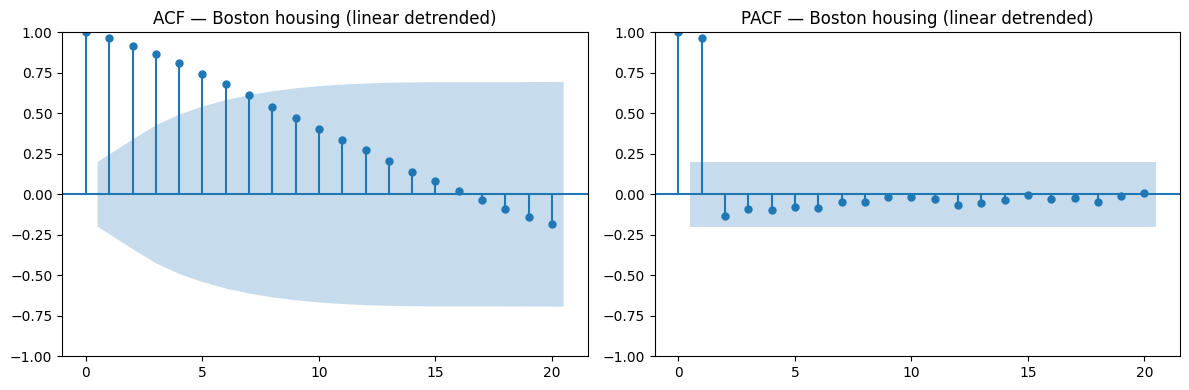

In [154]:
# plot ACF and PACF side by side

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ACF: autocorrelation at each lag
plot_acf(stationary, lags=20, ax=axes[0])
axes[0].set_title('ACF — Boston housing (linear detrended)')

# PACF: partial autocorrelation at each lag
plot_pacf(stationary, lags=20, ax=axes[1])
axes[1].set_title('PACF — Boston housing (linear detrended)')

plt.tight_layout()
plt.savefig('boston_acf_pacf.png', dpi=150)
plt.show()

for the first chart plots the autocorrelation function. The shaded region is the 95% confidence interval; bars outside it are statistically significant.

for the second one plots the partial autocorrelation, which isolates the direct effect of each lag (removing influence of intermediate lags).

ACF slowly decaying → the series still has strong serial correlation (typical of prices). PACF cutting off sharply after lag 1 → suggests an AR(1) process may be a good model.

The "simplest option" from the stationarity question was linear detrending (degree=1), since that was the first polynomial to make p < 0.05.


Problem 2: Time-Series Prediction

Consider fitting an AR(p) model to the Boston housing prices (with trend removal). Here, we will consider the time series from January 1st, 2010 to December 31st, 2017 as the training (in-sample) portion and the time series from January 1st, 2018 to December 31st, 2019 as the test (out-sample) portion.

Model Calibration

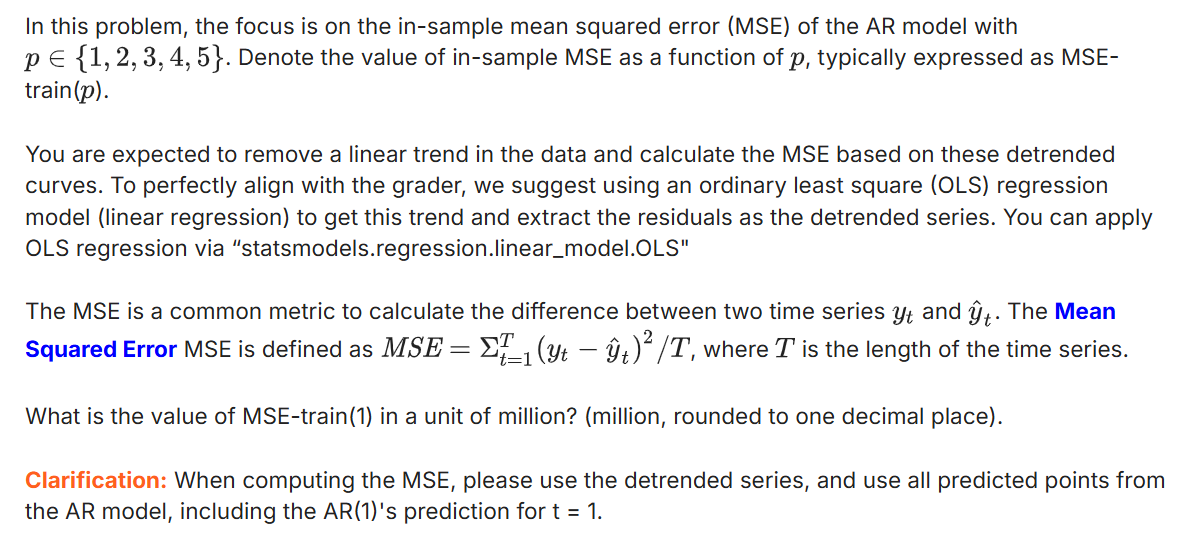

In [155]:
boston = df[df['RegionName'] == 'Boston, MA']
date_cols = [c for c in df.columns if c.startswith('20')]
prices = boston[date_cols].iloc[0]
prices.index = pd.to_datetime(prices.index)

In [156]:
train = prices[(prices.index >= '2010-01-01') & (prices.index <= '2017-12-31')] #because we were asked to include data from 2010 to 2017

In [157]:
#removing the linear trend using OLS method

t_train = np.arange(len(train))
X_train = sm.add_constant(t_train)   # adds intercept column

In [158]:
ols_model = OLS(train.values, X_train).fit()
trend_train  = ols_model.predict(X_train)
detrended_train = train.values - trend_train

In [159]:
#fitting AR(p) and computing MSE-train for p = 1.5
T = len(detrended_train)

for p in range(1, 6):
    model = AutoReg(detrended_train, lags=p, old_names=False).fit()

    # fittedvalues covers t = p..T-1 (length T-p)
    # Pad front with zeros for t = 0..p-1 (as required by the problem)
    preds_full = np.concatenate([np.zeros(p), model.fittedvalues])

    # MSE = sum of squared errors / T  (all T points)
    mse = np.sum((detrended_train - preds_full)**2) / T

    print(f"AR({p}): MSE-train = {mse/1e6:.1f} million")

AR(1): MSE-train = 11.5 million
AR(2): MSE-train = 19.7 million
AR(3): MSE-train = 29.5 million
AR(4): MSE-train = 39.1 million
AR(5): MSE-train = 48.3 million


Times Series Prediction

We will next use the optimal p  value to formulate an AR(p) model. You may check the answer above, and make sure you are using the correct p before solving the following questions.

Below, two forecasting strategies are taken into consideration:

- Long-Term Prediction: This strategy follows the regular setting to train a AR(p) model using the training dataset (up to December 2017). After that, make an one-shot prediction for the upcoming months during the test dates (January 2018 to December 2019). There is no model updates after the initial training.

- Short-Term Prediction: This strategy assumes that the AR(p) model can be rollingly updated with the latest observation data (the data volume for training is gradually increasing). For example, the point estimate for May 2018 is made by an updated AR(p) model which takes an extended training dataset (up to April 2018) as inputs. This rolling process can be applied for the entire test dates until December 2019. Note that the linear trend model is not updated.

Focusing on the forecasting performance of May 2018 (only one month), what are the MSE performances for long-term and short-term predictions?

Note : All results should be given in the unit of thousand and rounded to two decimal places. You are suggested to use the ARIMA model from statsmodels.tsa.arima.model to implement the AR model by setting d = q = 0

In [160]:
boston = df[df['RegionName'] == 'Boston, MA']
date_cols = [c for c in df.columns if c.startswith('20')]
prices = boston[date_cols].iloc[0]
prices.index = pd.to_datetime(prices.index)

In [161]:
train = prices[(prices.index >= '2010-01-01') & (prices.index <= '2017-12-31')]
test  = prices[(prices.index >= '2018-01-01') & (prices.index <= '2019-12-31')]

In [162]:
# OLS linear detrend
t_train = np.arange(len(train))
X_train = sm.add_constant(t_train)
ols_model = OLS(train.values, X_train).fit()
a, b = ols_model.params[0], ols_model.params[1]

In [163]:
def trend_at(t):
    return a + b * t

In [164]:
trend_train   = np.array([trend_at(t) for t in range(len(train))])
detrended_train = train.values - trend_train

In [165]:
# optimal p
p = 2

In [166]:
#get actual detrended value for May 2018

may2018_idx = 4
t_may = len(train) + may2018_idx
actual_may2018 = test.iloc[may2018_idx] - trend_at(t_may)

In [167]:
#long term prediction  (train once, forecast 5 steps ahead)
lt_model    = ARIMA(detrended_train, order=(p, 0, 0)).fit()
lt_forecast = lt_model.forecast(steps=may2018_idx + 1)
lt_pred     = float(lt_forecast[may2018_idx])

lt_mse = (actual_may2018 - lt_pred) ** 2
print(f"Long-term MSE: {lt_mse/1e3:.2f} thousand")

Long-term MSE: 37758.05 thousand


In [168]:
#short term prediction  (extend training to Apr 2018, forecast 1 step)
extended = prices[(prices.index >= '2010-01-01') & (prices.index <= '2018-04-30')]
n_ext = len(extended)
trend_extended    = np.array([trend_at(t) for t in range(n_ext)])
detrended_extended = extended.values - trend_extended

st_model    = ARIMA(detrended_extended, order=(p, 0, 0)).fit()
st_pred     = float(st_model.forecast(steps=1)[0])

st_mse = (actual_may2018 - st_pred) ** 2
print(f"Short-term MSE: {st_mse/1e3:.2f} thousand")

Short-term MSE: 23.75 thousand


Let MSE-test(p) denotes the out-sample MSE metric. With this notation, what is the out-sample MSE for the above two predictions?

In [169]:
T_test = len(test)   # 24 months
p = 2


In [170]:
# Actual detrended values for all 24 test months
actual_detrended_test = np.array([
    test.iloc[i] - trend_at(len(train) + i) for i in range(T_test)
])

In [171]:
#long-term MSE-test — one-shot forecast for all 24 months
lt_model    = ARIMA(detrended_train, order=(p, 0, 0)).fit()
lt_forecast = lt_model.forecast(steps=T_test)
lt_preds    = np.array([float(lt_forecast[i]) for i in range(T_test)])

lt_mse = np.mean((actual_detrended_test - lt_preds) ** 2)
print(f"Long-term MSE-test: {lt_mse/1e3:.2f} thousand")

Long-term MSE-test: 88002.75 thousand


In [172]:
###short-term MSE-test — rolling retrain, 1-step forecast each month
st_preds = []

for i in range(T_test):
    # Extend training up to the month before test[i]
    cutoff = test.index[i] - pd.DateOffset(months=1)
    extended = prices[(prices.index >= '2010-01-01') & (prices.index <= cutoff)]

    n_ext = len(extended)
    trend_extended    = np.array([trend_at(t) for t in range(n_ext)])
    detrended_extended = extended.values - trend_extended

    # Retrain AR(5) on extended data, forecast 1 step
    st_model = ARIMA(detrended_extended, order=(p, 0, 0)).fit()
    st_preds.append(float(st_model.forecast(steps=1)[0]))

st_mse = np.mean((actual_detrended_test - np.array(st_preds)) ** 2)
print(f"Short-term MSE-test: {st_mse/1e3:.2f} thousand")

###The for loop in the short-term strategy is the rolling window — each iteration retrains on one more month of data before making the next 1-step forecast.##

Short-term MSE-test: 1177.42 thousand


Problem 3: Time-Series Prediction With Exogenous Inputs

The next step is to try different model options for the time-series prediction, and remember to stablize the time series using the trend removal you've applied in Project 1.

Our focus is on two extensions: ARX and ARMAX models. Here an exogenous input of interest rates will be taken into consideration. Recall that you can get the interest rate data from FRED. You are expected to transform the weekly data into monthly data by resampling and then averaging. That is, for each month, you get 4-5 weekly data points, and you should average them to get an estimation for this month.

The settings for these two extensions are given below:

ARX(p): An autoregressive model with exogenous inputs. Use the interest rate data from FRED as an exogenous input into the model.

ARMAX(p,q ): An autoregressive moving average model with exogenous inputs. The same exogenous variable as ARX(p) is applied.

The task is to optimize the selections of p and q for both the ARX(p) and ARMAX(p,q ) models. Assume that  and . The evaluation metrics include the training (in-sample) MSE and the test (out-sample) MSE, and the short-term prediction strategy is implemented when deriving the test MSE.

Hint : You are suggested to use the ARIMA model from “statsmodels.tsa.arima.model" to implement the time series model by setting  and including the external variables in the exog input. To align with the grader, you should only use endog, exog, order, and trend arguments in your ARIMA model. You need to decide the suitable endog, exog and order, and then set “trend="n"" to enforce no constant term in the regression. This is because we have removed a linear trend first that should cancel out the contant shifts from the data (so that the residual series is expected to be zero mean). We keep default settings for other options.

Hint : You might encounter MLE convergence warnings because of some numerical issues. In this project, you may want to use “warnings.simplefilter("ignore", statsmodels.tools.sm_exceptions.ConvergenceWarning)" (with the package warnings and statsmodels imported) to skip these warnings. Another common error is LU decomposition errors. You can use the try-except block to go ahead and set the associated settings as unreliable. It is also possible to set “enforce_stationarity=False" to avoid such errors but the regression formulations and results can be different from the grader.


Calibration of ARX(p)
In terms of training (in-sample) MSE, what is the optimal selection of p for ARX(p) models?

In [173]:
# Average weekly data points within each month


df1 = pd.read_csv('data_interest_rates.csv')
df1['DATE'] = pd.to_datetime(df1['DATE'])
df1 = df1.set_index('DATE')

ir_monthly = df1['MORTGAGE30US'].resample('ME').mean() / 100

ir_train = ir_monthly[(ir_monthly.index >= '2010-01-01') & (ir_monthly.index <= '2017-12-31')]
ir_test  = ir_monthly[(ir_monthly.index >= '2018-01-01') & (ir_monthly.index <= '2019-12-31')]

In [174]:
# ARX(p) in-sample MSE
for p in range(1, 6):
    # exog= passes the interest rate as exogenous variable
    model  = ARIMA(detrended_train, exog=ir_train.values,
                   order=(p, 0, 0)).fit()
    fitted = model.fittedvalues
    mse    = np.mean((detrended_train[p:] - fitted[p:]) ** 2)
    print(f"ARX({p}): MSE-train = {mse/1e3:.4f} thousand")

ARX(1): MSE-train = 7967.9899 thousand
ARX(2): MSE-train = 7019.9342 thousand
ARX(3): MSE-train = 7072.6642 thousand
ARX(4): MSE-train = 7079.0705 thousand
ARX(5): MSE-train = 6837.6807 thousand


In [175]:
train_prices = prices[(prices.index >= '2010-01-01') & (prices.index <= '2017-12-31')]
test_prices  = prices[(prices.index >= '2018-01-01') & (prices.index <= '2019-12-31')]
ir_train = ir_monthly[(ir_monthly.index >= '2010-01-01') & (ir_monthly.index <= '2017-12-31')]

In [176]:
# --- ARX(p) out-sample MSE (rolling) ---
print("=== ARX(p) Out-Sample MSE ===")
for p in range(1, 6):
    st_preds = []
    for i in range(T_test):
        cutoff   = test_prices.index[i] - pd.DateOffset(months=1)
        ext_p    = prices[(prices.index >= '2010-01-01') & (prices.index <= cutoff)]
        ext_ir   = ir_monthly[(ir_monthly.index >= '2010-01-01') & (ir_monthly.index <= cutoff)]
        det_ext  = ext_p.values - np.array([trend_at(t) for t in range(len(ext_p))])
        next_ir  = ir_monthly[test_prices.index[i]:test_prices.index[i]].values
        st_model = ARIMA(det_ext, exog=ext_ir.values, order=(p, 0, 0)).fit()
        st_preds.append(float(st_model.forecast(steps=1, exog=next_ir)[0]))
    mse = np.mean((actual_detrended_test - np.array(st_preds))**2)
    print(f"ARX({p}): MSE-test = {mse/1e3:.4f} thousand")

=== ARX(p) Out-Sample MSE ===
ARX(1): MSE-test = 9679.6147 thousand
ARX(2): MSE-test = 8747.1433 thousand
ARX(3): MSE-test = 8771.9919 thousand
ARX(4): MSE-test = 8846.5445 thousand
ARX(5): MSE-test = 8751.3908 thousand


Change of Training and Test Data


Consider a regular AR(2) and a regular ARX(2) model. Retrain this model using data from January 1st, 2010 to December 31st, 2019, and consider a test set of January 1st, 2020 to December 31st, 2021. The short-term prediction strategy is applied in this problem as well.

For AR(2), what is the impact of modifying the training and test datasets?

In [177]:
boston = df[df['RegionName'] == 'Boston, MA']
date_cols = [c for c in df.columns if c.startswith('20')]
prices = boston[date_cols].iloc[0]
prices.index = pd.to_datetime(prices.index)

In [178]:
 #New split: train 2010–2019, test 2020–2021
train_prices = prices[(prices.index >= '2010-01-01') & (prices.index <= '2019-12-31')]
test_prices  = prices[(prices.index >= '2020-01-01') & (prices.index <= '2021-12-31')]

In [179]:
# OLS linear detrend on new training data
t_train = np.arange(len(train_prices))
X_train = sm.add_constant(t_train)
ols_model = OLS(train_prices.values, X_train).fit()
a, b = ols_model.params[0], ols_model.params[1]

def trend_at(t):
    return a + b * t

detrended_train = train_prices.values - np.array([trend_at(t) for t in range(len(train_prices))])

In [180]:
# AR(2) in-sample MSE
p = 2
model = ARIMA(detrended_train, order=(p, 0, 0)).fit()

fitted = np.array(model.fittedvalues)
fitted[:p] = 0.0   # zero-pad first p unpredictable points

mse_train = np.mean((detrended_train - fitted) ** 2)
print(f"AR(2) MSE-train: {mse_train/1e6:.4f} million")

AR(2) MSE-train: 22.9354 million


In [ ]:
#AR(2) out-sample MSE (short-term rolling)
T_test = len(test_prices)
actual_detrended_test = np.array([
    test_prices.iloc[i] - trend_at(len(train_prices) + i)
    for i in range(T_test)
])

st_preds = []
for i in range(T_test):
    cutoff  = test_prices.index[i] - pd.DateOffset(months=1)
    ext_p   = prices[(prices.index >= '2010-01-01') & (prices.index <= cutoff)]
    n       = len(ext_p)
    det_ext = ext_p.values - np.array([trend_at(t) for t in range(n)])
    st_model = ARIMA(det_ext, order=(p, 0, 0)).fit()
    st_preds.append(float(st_model.forecast(steps=1)[0]))

mse_test = np.mean((actual_detrended_test - np.array(st_preds)) ** 2)
print(f"AR(2) MSE-test:  {mse_test/1e6:.4f} million")